In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhilvarmakandula/flight-delay-analysis")

print("Path to dataset files:", path)

100%|██████████| 45.5M/45.5M [00:00<00:00, 187MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nikhilvarmakandula/flight-delay-analysis/versions/4


In [4]:
import os
import pandas as pd
print(os.listdir(path))

['README.md', 'flight_delay_analysis.ipynb', 'requirements.txt', 'figures', '.gitignore', 'LICENSE', 'README_data.md', 'flights_sample_3m.csv']


In [5]:
df = pd.read_csv(os.path.join(path, "flights_sample_3m.csv"))
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,09-01-2019,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0,186.0,176.0,153.0,1065,NaN,NaN,NaN,NaN,NaN
1,19-11-2022,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0,235.0,236.0,189.0,1399,NaN,NaN,NaN,NaN,NaN
2,22-07-2022,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0,118.0,112.0,87.0,680,NaN,NaN,NaN,NaN,NaN
3,06-03-2023,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0,260.0,285.0,249.0,1589,0.0,0.0,24.0,0.0,0.0
4,23-02-2020,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0,181.0,182.0,153.0,985,NaN,NaN,NaN,NaN,NaN


## Data Cleaning and Preparation

First, let's inspect the data types and check for missing values using `df.info()` and descriptive statistics using `df.describe()` to understand the dataset's structure.

In [6]:
print(df.info())
print("\n" + "="*50 + "\n")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   FL_DATE                  1048575 non-null  object 
 1   AIRLINE                  1048575 non-null  object 
 2   AIRLINE_DOT              1048575 non-null  object 
 3   AIRLINE_CODE             1048575 non-null  object 
 4   DOT_CODE                 1048575 non-null  int64  
 5   FL_NUMBER                1048575 non-null  int64  
 6   ORIGIN                   1048575 non-null  object 
 7   ORIGIN_CITY              1048575 non-null  object 
 8   DEST                     1048575 non-null  object 
 9   DEST_CITY                1048575 non-null  object 
 10  CRS_DEP_TIME             1048575 non-null  int64  
 11  DEP_TIME                 1021527 non-null  float64
 12  DEP_DELAY                1021518 non-null  float64
 13  TAXI_OUT                 1021103 non-null 

From the `info()` output, we can see several columns have missing values, especially the `DELAY_DUE_*` columns. The `FL_DATE` column is currently an object (string) and needs to be converted to a datetime format for proper time-series analysis.

### Handling Missing Values and Data Type Conversion

1.  **Convert `FL_DATE` to datetime**: This will allow for easier manipulation and analysis of dates.
2.  **Fill `DELAY_DUE_*` NaN values**: The `DELAY_DUE_CARRIER`, `DELAY_DUE_WEATHER`, `DELAY_DUE_NAS`, `DELAY_DUE_SECURITY`, and `DELAY_DUE_LATE_AIRCRAFT` columns represent the duration of delays due to specific reasons. `NaN` values in these columns likely indicate no delay for that particular reason. Therefore, we will fill these `NaN` values with `0`.
3.  **Review other numerical missing values**: Based on `df.info()`, other numerical columns (`CRS_ELAPSED_TIME`, `ELAPSED_TIME`, `AIR_TIME`) also have some missing values. For now, we will fill these with 0 as well, assuming that missing values mean 0 time, or no value was recorded.

In [7]:
# Convert FL_DATE to datetime objects
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='%d-%m-%Y', errors='coerce')

# Columns related to delay reasons
delay_reason_cols = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

# Fill NaN values in delay reason columns with 0
df[delay_reason_cols] = df[delay_reason_cols].fillna(0)

# Fill other numerical missing values with 0
numeric_cols_to_fill = ['CRS_ELAPSED_TIME', 'ELAPSED_TIME', 'AIR_TIME']
df[numeric_cols_to_fill] = df[numeric_cols_to_fill].fillna(0)



# Display updated info and head to confirm changes
print(df.info())
print("\n" + "="*50 + "\n")
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   FL_DATE                  1048575 non-null  datetime64[ns]
 1   AIRLINE                  1048575 non-null  object        
 2   AIRLINE_DOT              1048575 non-null  object        
 3   AIRLINE_CODE             1048575 non-null  object        
 4   DOT_CODE                 1048575 non-null  int64         
 5   FL_NUMBER                1048575 non-null  int64         
 6   ORIGIN                   1048575 non-null  object        
 7   ORIGIN_CITY              1048575 non-null  object        
 8   DEST                     1048575 non-null  object        
 9   DEST_CITY                1048575 non-null  object        
 10  CRS_DEP_TIME             1048575 non-null  int64         
 11  DEP_TIME                 1021527 non-null  float64       
 12  

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0,186.0,176.0,153.0,1065,0.0,0.0,0.0,0.0,0.0
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0,235.0,236.0,189.0,1399,0.0,0.0,0.0,0.0,0.0
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0,118.0,112.0,87.0,680,0.0,0.0,0.0,0.0,0.0
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0,260.0,285.0,249.0,1589,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0,181.0,182.0,153.0,985,0.0,0.0,0.0,0.0,0.0


df

In [8]:
df.shape

(1048575, 32)

In [9]:
print('Number of remaining missing values before cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill NaN values in 'CANCELLATION_CODE' with 'None'
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('None')

# Columns with remaining numerical missing values (based on df.info() and prior steps)
remaining_numeric_cols_to_fill = [
    'DEP_TIME',
    'DEP_DELAY',
    'TAXI_OUT',
    'WHEELS_OFF',
    'WHEELS_ON',
    'TAXI_IN',
    'ARR_TIME',
    'ARR_DELAY'
]

# Fill these remaining numerical NaN values with 0
df[remaining_numeric_cols_to_fill] = df[remaining_numeric_cols_to_fill].fillna(0)

print('\n' + '='*50 + '\n')
print('Number of missing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Number of remaining missing values before cleaning:
DEP_TIME               27048
DEP_DELAY              27057
TAXI_OUT               27472
WHEELS_OFF             27472
WHEELS_ON              27866
TAXI_IN                27866
ARR_TIME               27866
ARR_DELAY              30005
CANCELLATION_CODE    1020978
dtype: int64


Number of missing values after cleaning:
Series([], dtype: int64)


Now that all missing values have been addressed, let's review the `df.info()` to confirm and then we can proceed with statistical analysis.

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 32 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   FL_DATE                  1048575 non-null  datetime64[ns]
 1   AIRLINE                  1048575 non-null  object        
 2   AIRLINE_DOT              1048575 non-null  object        
 3   AIRLINE_CODE             1048575 non-null  object        
 4   DOT_CODE                 1048575 non-null  int64         
 5   FL_NUMBER                1048575 non-null  int64         
 6   ORIGIN                   1048575 non-null  object        
 7   ORIGIN_CITY              1048575 non-null  object        
 8   DEST                     1048575 non-null  object        
 9   DEST_CITY                1048575 non-null  object        
 10  CRS_DEP_TIME             1048575 non-null  int64         
 11  DEP_TIME                 1048575 non-null  float64       
 12  

## Exploratory Data Analysis (EDA)

Now that the data cleaning and preparation, including handling of missing values, is complete, let's perform some exploratory data analysis to understand the dataset better. We will start by looking at descriptive statistics and then visualize key distributions.

### 1. Descriptive Statistics

Let's review the descriptive statistics for numerical columns, now that missing values have been filled. This will help us understand the central tendency, dispersion, and shape of our dataset's distribution.

In [11]:
print(df.describe())

                             FL_DATE      DOT_CODE     FL_NUMBER  \
count                        1048575  1.048575e+06  1.048575e+06   
mean   2021-05-08 12:45:37.617052160  1.997643e+04  2.511431e+03   
min              2019-01-01 00:00:00  1.939300e+04  1.000000e+00   
25%              2019-12-27 00:00:00  1.979000e+04  1.051000e+03   
50%              2021-06-29 00:00:00  1.993000e+04  2.152000e+03   
75%              2022-08-03 00:00:00  2.036800e+04  3.796000e+03   
max              2023-08-31 00:00:00  2.045200e+04  9.562000e+03   
std                              NaN  3.773195e+02  1.746354e+03   

       CRS_DEP_TIME      DEP_TIME     DEP_DELAY      TAXI_OUT    WHEELS_OFF  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   1.327044e+03  1.295451e+03  9.861552e+00  1.620428e+01  1.317011e+03   
min    1.000000e+00  0.000000e+00 -8.200000e+01  0.000000e+00  0.000000e+00   
25%    9.150000e+02  8.550000e+02 -6.000000e+00  1.100000e+01  9.110000

### 2. Distribution of Flight Delays

Understanding the distribution of `DEP_DELAY` (departure delay) and `ARR_DELAY` (arrival delay) is crucial. We will use histograms to visualize these distributions and identify common delay patterns.

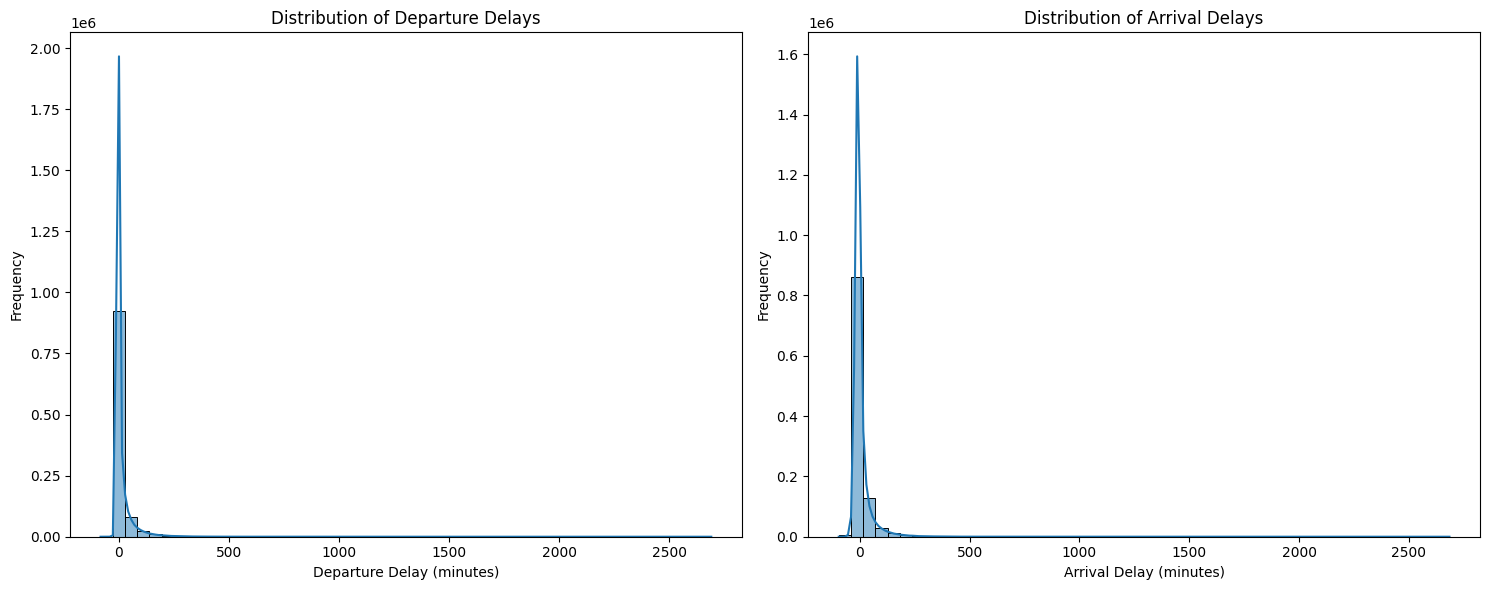

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Distribution of Departure Delays
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(df['DEP_DELAY'], bins=50, kde=True)
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency')

# Distribution of Arrival Delays
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(df['ARR_DELAY'], bins=50, kde=True)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### 3. Analysis of Cancellation Reasons

Now let's examine the `CANCELLATION_CODE` column to see the frequency of different cancellation reasons. Remember that 'None' now represents flights that were not cancelled.

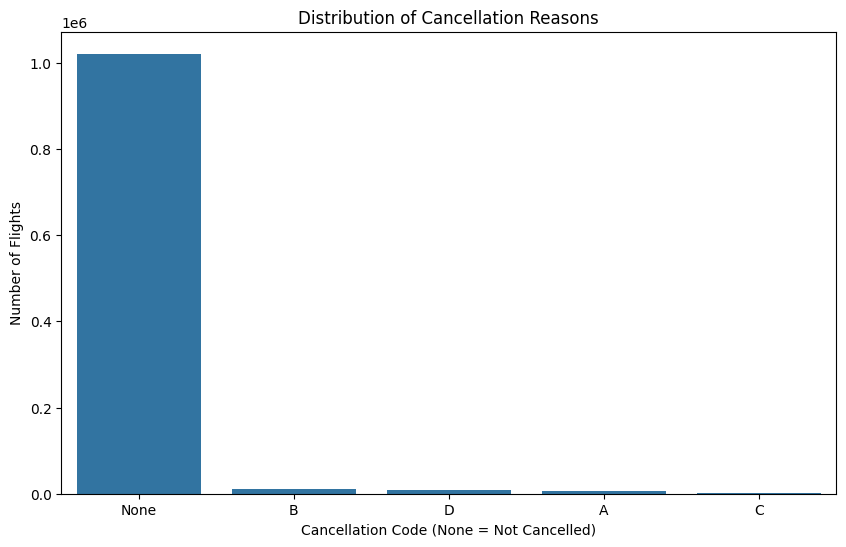

In [13]:
cancellation_counts = df['CANCELLATION_CODE'].value_counts().reset_index()
cancellation_counts.columns = ['Cancellation Code', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Cancellation Code', y='Count', data=cancellation_counts)
plt.title('Distribution of Cancellation Reasons')
plt.xlabel('Cancellation Code (None = Not Cancelled)')
plt.ylabel('Number of Flights')
plt.show()

### 4. Analysis of Top Airlines, Origin, and Destination Airports

Let's identify the most frequent airlines, origin airports, and destination airports in our dataset. This can provide context for where most of the flight activity is concentrated.

In [16]:
print('Top 10 Airlines:')
print(df['AIRLINE_DOT'].value_counts().head(10))
print('\n' + '='*50 + '\n')

print('Top 10 Origin Airports:')
print(df['ORIGIN_CITY'].value_counts().head(10))
print('\n' + '='*50 + '\n')

print('Top 10 Destination Airports:')
print(df['DEST_CITY'].value_counts().head(10))

Top 10 Airlines:
AIRLINE_DOT
Southwest Airlines Co.: WN    201496
Delta Air Lines Inc.: DL      138122
American Airlines Inc.: AA    133714
SkyWest Airlines Inc.: OO     120090
United Air Lines Inc.: UA      89063
Republic Airline: YX           49883
Envoy Air: MQ                  42669
Endeavor Air Inc.: 9E          39484
JetBlue Airways: B6            39372
PSA Airlines Inc.: OH          37276
Name: count, dtype: int64


Top 10 Origin Airports:
ORIGIN_CITY
Chicago, IL              55118
Atlanta, GA              53866
Dallas/Fort Worth, TX    45466
Denver, CO               42178
New York, NY             39570
Charlotte, NC            33043
Houston, TX              30413
Los Angeles, CA          29846
Washington, DC           27669
Phoenix, AZ              27026
Name: count, dtype: int64


Top 10 Destination Airports:
DEST_CITY
Chicago, IL              55390
Atlanta, GA              53654
Dallas/Fort Worth, TX    45632
Denver, CO               41734
New York, NY             39463
Charl

### 5. Average Delay by Airline

Let's investigate the average departure and arrival delays for the top airlines to see if there are significant differences between carriers.

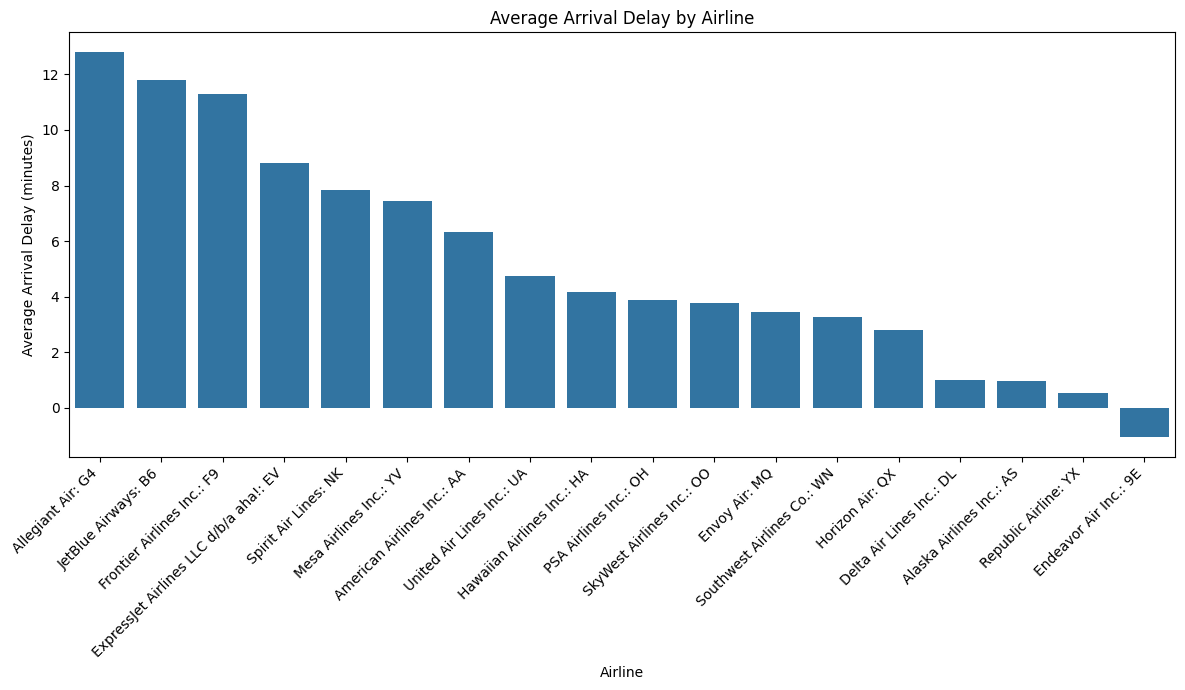

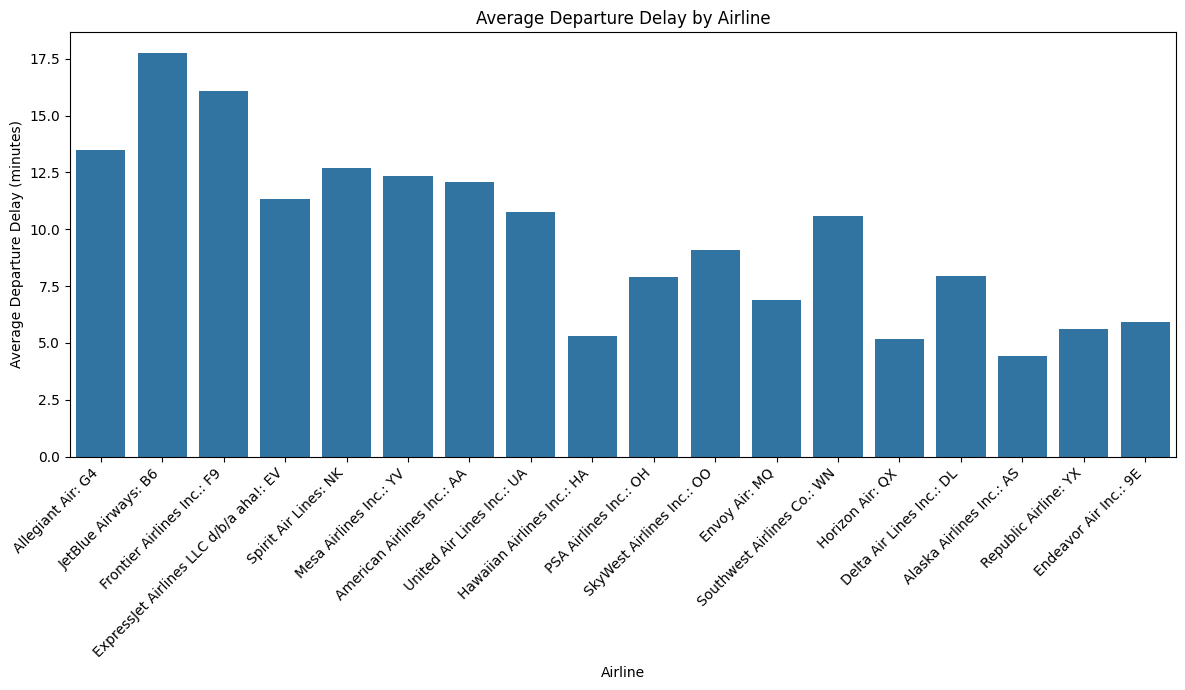

In [17]:
avg_delay_by_airline = df.groupby('AIRLINE_DOT')[['DEP_DELAY', 'ARR_DELAY']].mean().sort_values(by='ARR_DELAY', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_by_airline.index, y='ARR_DELAY', data=avg_delay_by_airline)
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_by_airline.index, y='DEP_DELAY', data=avg_delay_by_airline)
plt.title('Average Departure Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Departure Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6. Delays by Month

Let's analyze the average departure and arrival delays across different months to identify any seasonal trends.

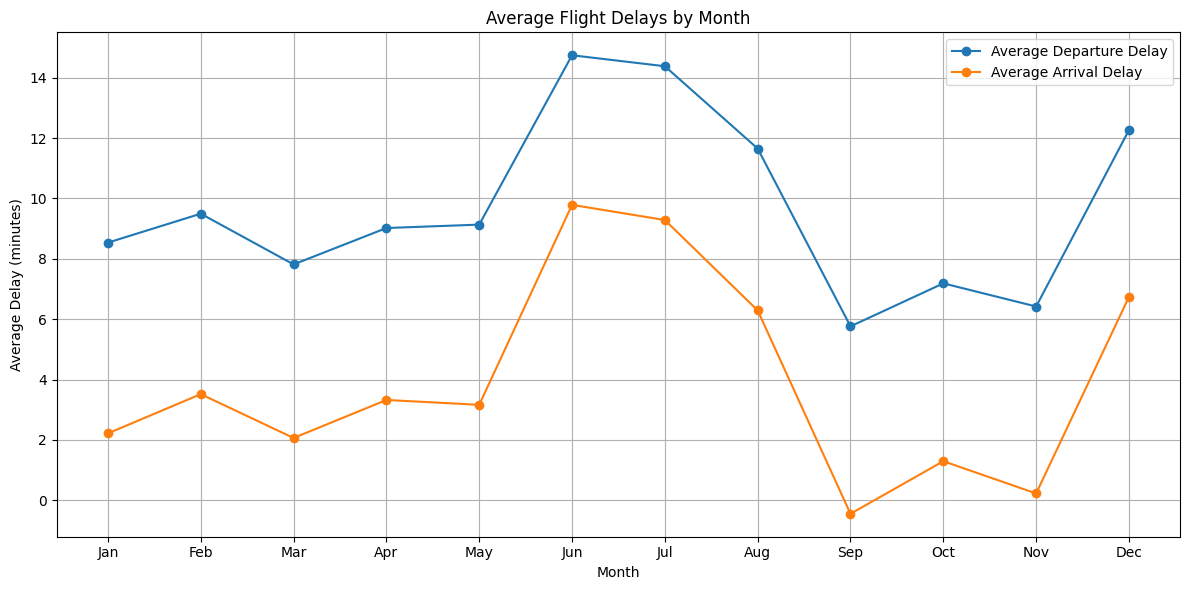

In [20]:
df['MONTH'] = df['FL_DATE'].dt.month
avg_delay_by_month = df.groupby('MONTH')[['DEP_DELAY', 'ARR_DELAY']].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_delay_by_month.index, avg_delay_by_month['DEP_DELAY'], marker='o', label='Average Departure Delay')
plt.plot(avg_delay_by_month.index, avg_delay_by_month['ARR_DELAY'], marker='o', label='Average Arrival Delay')
plt.title('Average Flight Delays by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 7. Delays by Day of Week

Now, let's explore how average delays differ by day of the week.

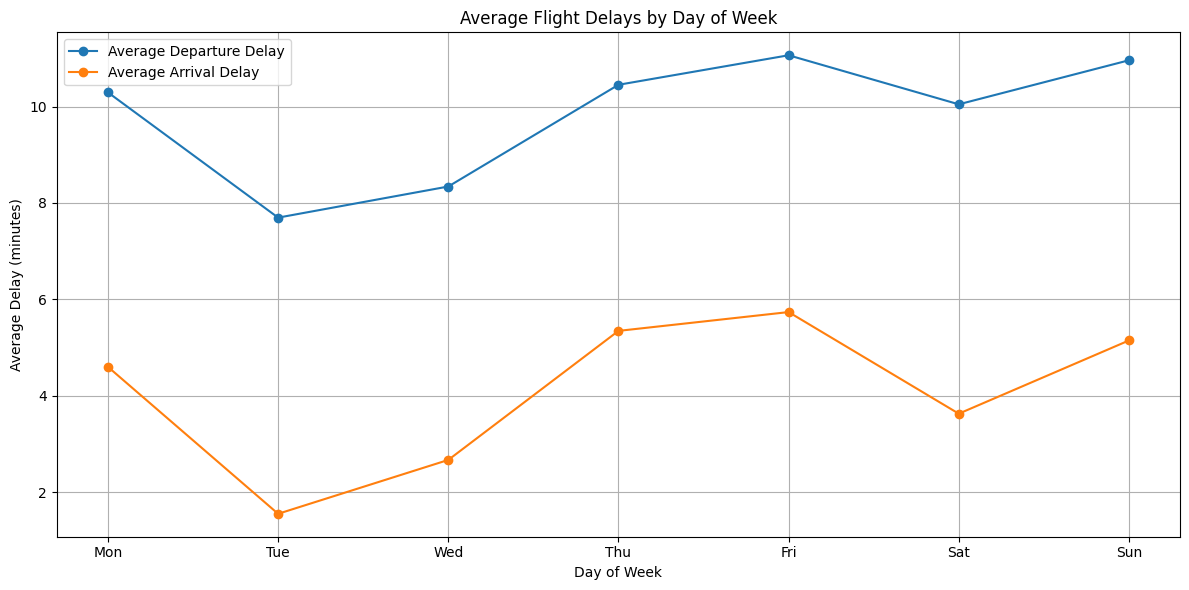

In [21]:
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek # Monday=0, Sunday=6
avg_delay_by_day = df.groupby('DAY_OF_WEEK')[['DEP_DELAY', 'ARR_DELAY']].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_delay_by_day.index, avg_delay_by_day['DEP_DELAY'], marker='o', label='Average Departure Delay')
plt.plot(avg_delay_by_day.index, avg_delay_by_day['ARR_DELAY'], marker='o', label='Average Arrival Delay')
plt.title('Average Flight Delays by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 6. Delays by Month

Let's analyze the average departure and arrival delays across different months to identify any seasonal trends.

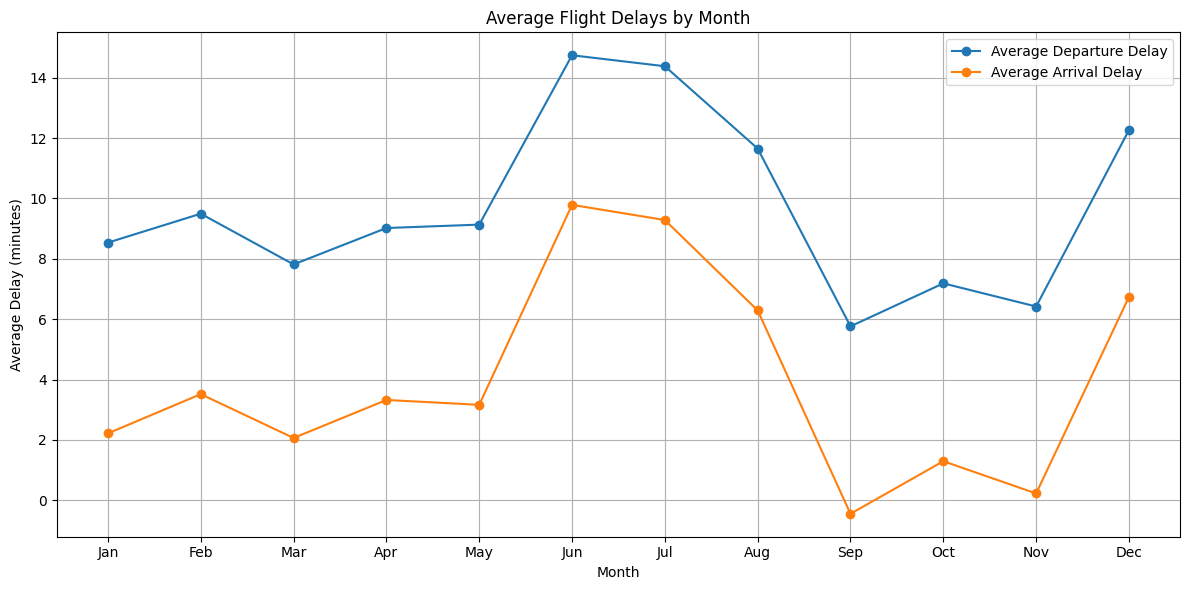

In [18]:
df['MONTH'] = df['FL_DATE'].dt.month
avg_delay_by_month = df.groupby('MONTH')[['DEP_DELAY', 'ARR_DELAY']].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_delay_by_month.index, avg_delay_by_month['DEP_DELAY'], marker='o', label='Average Departure Delay')
plt.plot(avg_delay_by_month.index, avg_delay_by_month['ARR_DELAY'], marker='o', label='Average Arrival Delay')
plt.title('Average Flight Delays by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 7. Delays by Day of Week

Now, let's explore how average delays differ by day of the week.

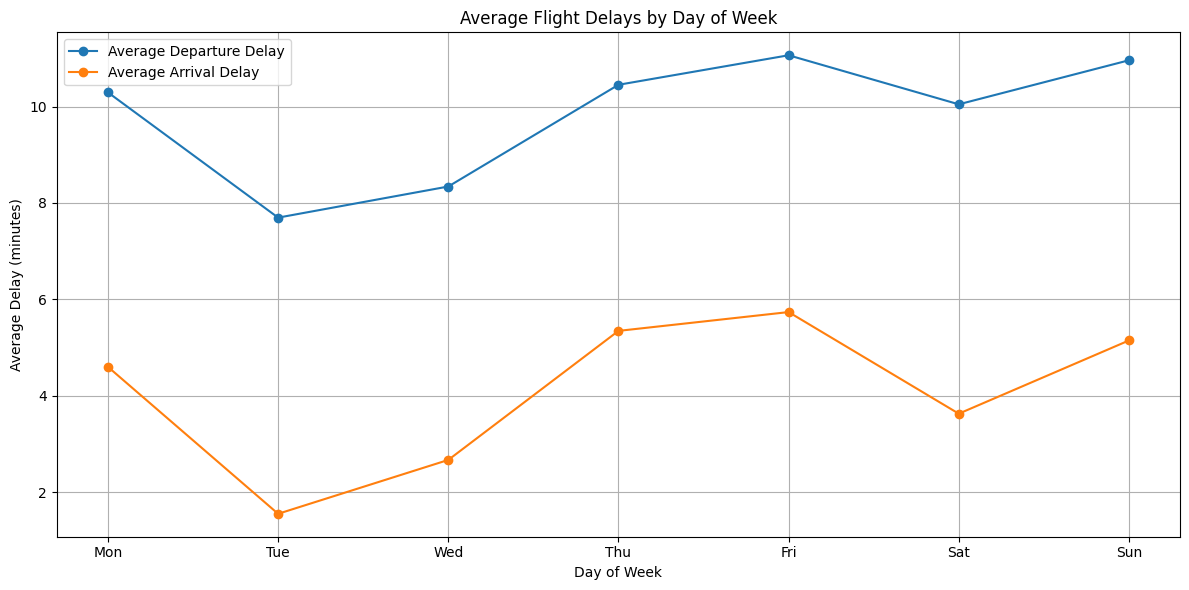

In [19]:
df['DAY_OF_WEEK'] = df['FL_DATE'].dt.dayofweek # Monday=0, Sunday=6
avg_delay_by_day = df.groupby('DAY_OF_WEEK')[['DEP_DELAY', 'ARR_DELAY']].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_delay_by_day.index, avg_delay_by_day['DEP_DELAY'], marker='o', label='Average Departure Delay')
plt.plot(avg_delay_by_day.index, avg_delay_by_day['ARR_DELAY'], marker='o', label='Average Arrival Delay')
plt.title('Average Flight Delays by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Delay (minutes)')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 4. Analysis of Top Airlines, Origin, and Destination Airports

Let's identify the most frequent airlines, origin airports, and destination airports in our dataset. This can provide context for where most of the flight activity is concentrated.

In [14]:
print('Top 10 Airlines:')
print(df['AIRLINE_DOT'].value_counts().head(10))
print('\n' + '='*50 + '\n')

print('Top 10 Origin Airports:')
print(df['ORIGIN_CITY'].value_counts().head(10))
print('\n' + '='*50 + '\n')

print('Top 10 Destination Airports:')
print(df['DEST_CITY'].value_counts().head(10))

Top 10 Airlines:
AIRLINE_DOT
Southwest Airlines Co.: WN    201496
Delta Air Lines Inc.: DL      138122
American Airlines Inc.: AA    133714
SkyWest Airlines Inc.: OO     120090
United Air Lines Inc.: UA      89063
Republic Airline: YX           49883
Envoy Air: MQ                  42669
Endeavor Air Inc.: 9E          39484
JetBlue Airways: B6            39372
PSA Airlines Inc.: OH          37276
Name: count, dtype: int64


Top 10 Origin Airports:
ORIGIN_CITY
Chicago, IL              55118
Atlanta, GA              53866
Dallas/Fort Worth, TX    45466
Denver, CO               42178
New York, NY             39570
Charlotte, NC            33043
Houston, TX              30413
Los Angeles, CA          29846
Washington, DC           27669
Phoenix, AZ              27026
Name: count, dtype: int64


Top 10 Destination Airports:
DEST_CITY
Chicago, IL              55390
Atlanta, GA              53654
Dallas/Fort Worth, TX    45632
Denver, CO               41734
New York, NY             39463
Charl

### 5. Average Delay by Airline

Let's investigate the average departure and arrival delays for the top airlines to see if there are significant differences between carriers.

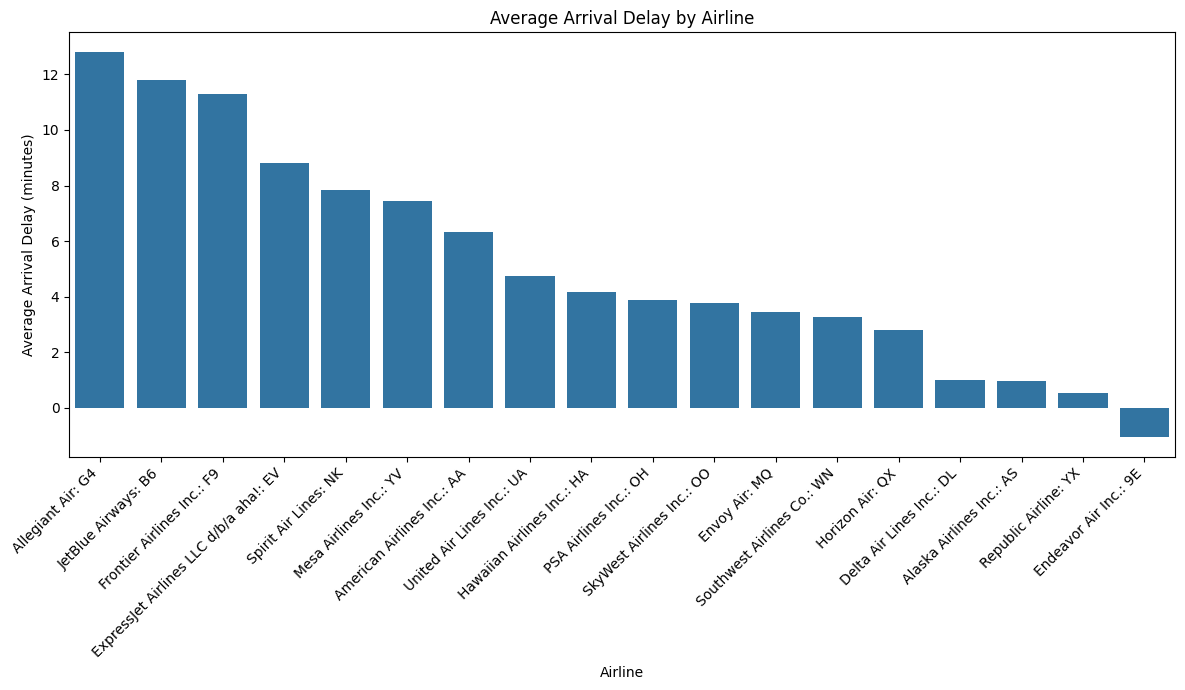

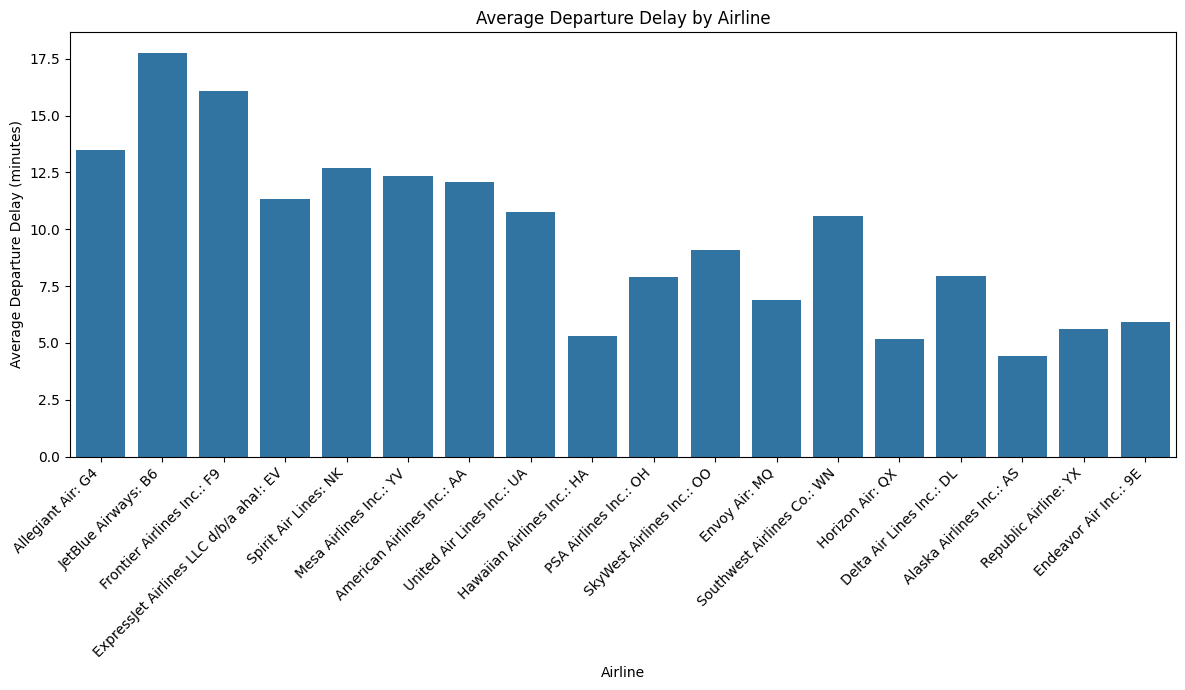

In [15]:
avg_delay_by_airline = df.groupby('AIRLINE_DOT')[['DEP_DELAY', 'ARR_DELAY']].mean().sort_values(by='ARR_DELAY', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_by_airline.index, y='ARR_DELAY', data=avg_delay_by_airline)
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x=avg_delay_by_airline.index, y='DEP_DELAY', data=avg_delay_by_airline)
plt.title('Average Departure Delay by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Departure Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()